In [37]:
import numpy as np 
import matplotlib.pyplot as plt
import soundfile as sf
from fractions import Fraction
from scipy.signal import resample_poly as res_poly


audio = 'audio_music.mp3'
fs_hz = 240000.0 #abtastrate
duration = 0.5 #sekunden
pilot = 19000
freq_hub = 75000
freq_cutoff = 15000

freq_send = 89.5e6
c = 3e8

print('loaded')

loaded


In [38]:
# Audio einelesen und in L und R aufteilen

data, fs_file = sf.read(audio, dtype="float64", always_2d=True)
left = data[:, 0]
right = data[:, 1] 

print('Abtastrate: ', fs_file, 'Hz')
print('Dauer: ', round(len(left)/fs_file, 2), 's')

Abtastrate:  44100 Hz
Dauer:  34.32 s


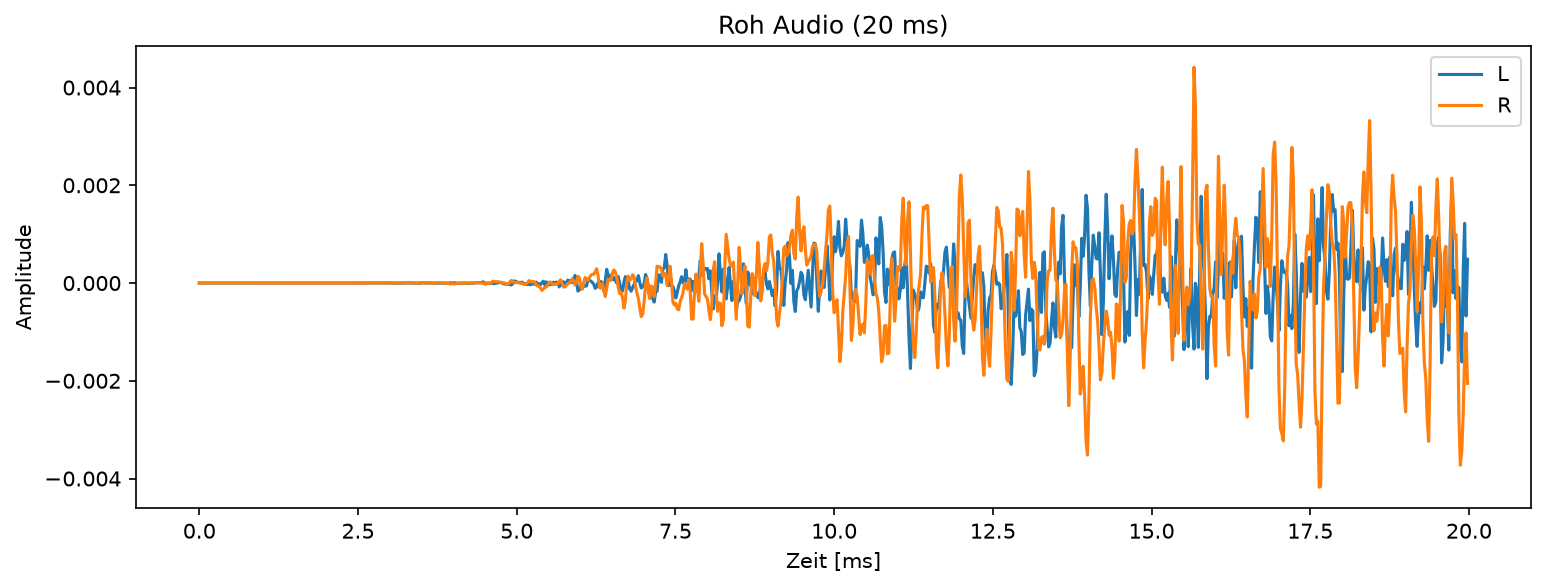

In [39]:
# Wellenform 20ms
fig, ax = plt.subplots(figsize=(12, 4), dpi =150)
n = int(0.02 * fs_file) 
t = np.arange(n) / fs_file * 1e3

plt.plot(t, left[:n], label = 'L')
plt.plot(t, right[:n], label= 'R')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.title('Roh Audio (20 ms)')
plt.legend()





In [40]:
# resample auf 240kHz
def res(x, fs_in, fs_out):
    #p/q
    ratio = Fraction(int(fs_out), int(fs_in))
    return res_poly(x, up=ratio.numerator, down=ratio.denominator)

left = res(left, fs_file, fs_hz)
right = res(right, fs_file, fs_hz)

m = int(duration * fs_hz)
left, right = left[:m], right[:m]

peak = max(np.max(np.abs(left)), np.max(np.abs(right)))
left, right = left / peak, right / peak


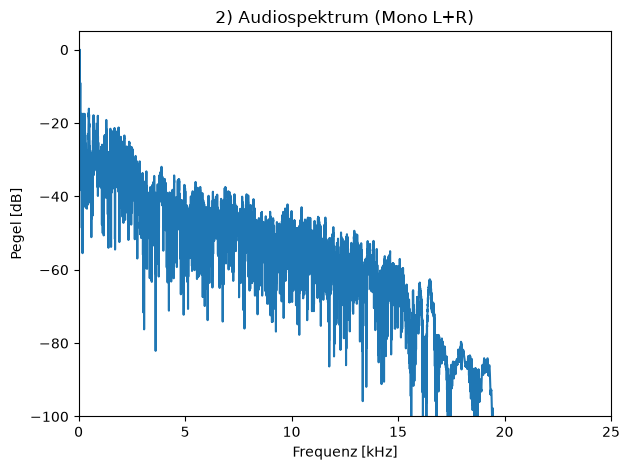

In [ ]:
# Spektrum plotten zur Veranschaulichung

def plot_spec(x, fs, fmax=None, title=''):
    X = np.fft.rfft(x * np.hanning(len(x)))
    f = np.fft.rfftfreq(len(x), 1.0/fs)
    magdb = 20 * np.log10(np.abs(X) + 1e-12)
    magdb -= magdb.max()

    plt.plot(f/1e3, magdb)                 
    if fmax: plt.xlim(0, fmax/1e3)
    plt.ylim(-100, 5)
    plt.xlabel('Frequenz [kHz]'); plt.ylabel('Pegel [dB]'); plt.title(title)

plot_spec(0.5*(left+right), fs_hz, fmax=25e3, title='2) Audiospektrum (Mono L+R)')
plt.tight_layout(); plt.show()
